In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
os.chdir('/home/jovyan/sdseSp26/final project')

In [2]:
# import data
data = pd.read_csv('resources/housing.csv')

In [3]:
# clean data just in case by dropping rows with no data
clean_data = data.dropna(axis=0, how='any')
clean_features = clean_data.drop(columns=['median_house_value']).columns
#print(clean_features)

In [4]:
# separate features (X) from target (y = price)
#X = clean_data.drop(columns=['median_house_value']).values
#y = clean_data['median_house_value'].values

In [5]:
def split_data(df, pt, pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    #shuffle data
    df = df.sample(frac=1, random_state=2434).reset_index(drop=True)

    N = len(df) # numnber of samples in raw_data
    data_train = df.copy().iloc[0:int(N*pt)]
    data_validate = df.copy().iloc[int(N*pt):int(N*pt+N*pv)]
    data_test = df.copy().iloc[(int(N*pt+N*pv)):]
    
    return data_train, data_validate, data_test

In [6]:
data_train, data_validate, data_test = split_data(clean_data,pt=0.7,pv=0.15)

In [7]:
# split data into training and testing sets
#from sklearn.model_selection import train_test_split
#Xtrain, Xtest, ytrain, ytest = train_test_split(X,
#                                                y,
#                                                test_size=0.2, # 20% for testing
#                                                random_state=42 )

In [8]:
# encode columns with strings ('ocean_proximity') and separate X and y
Xtrain = pd.get_dummies(data_train.drop(columns=['median_house_value']))
ytrain = data_train['median_house_value'].values
ytrain_log = np.log1p(data_train['median_house_value'].values)

Xvalidate = pd.get_dummies(data_validate.drop(columns=['median_house_value']))
yvalidate = data_validate['median_house_value'].values
yvalidate_log = np.log1p(data_validate['median_house_value'].values)

Xtest = pd.get_dummies(data_test.drop(columns=['median_house_value']))
ytest = data_test['median_house_value'].values
ytest_log = np.log1p(data_test['median_house_value'].values)

# reindex the encoding to match training data
Xvalidate = Xvalidate.reindex(columns=Xtrain.columns, fill_value=0)
Xtest = Xtest.reindex(columns=Xtrain.columns, fill_value=0)

In [9]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Use the fit_transform method to perform the normalization of columns
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xvalidate_scaled = scaler.transform(Xvalidate)
Xtest_scaled = scaler.transform(Xtest)

# Format the normalized input as a DataFrame
# Xtrain_norm = pd.DataFrame(X, index=Xtrain_scaled.index, columns=Xtrain.columns) 

In [10]:
#%pip install --upgrade pip
#%pip install --extra-index-url https://download.pytorch.org/whl/cpu torch

In [11]:
# import modules for neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [12]:
# Build an MLP
random.seed(2434)  
np.random.seed(2434)
torch.manual_seed(2434)

D = Xtrain_scaled.shape[1]

model_mlp = nn.Sequential(
    nn.Linear(D, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

for layer in model_mlp:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

random.seed(2434)  
np.random.seed(2434)
torch.manual_seed(2434)

model_mlp_log = nn.Sequential(
    nn.Linear(D, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

for layer in model_mlp_log:
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

In [13]:
# convert to tensors
Xtrain_t = torch.tensor(Xtrain_scaled, dtype=torch.float32)
ytrain_t = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1)
ytrain_log_t = torch.tensor(ytrain_log, dtype=torch.float32).reshape(-1,1)

Xvalidate_t = torch.tensor(Xvalidate_scaled, dtype=torch.float32)
yvalidate_t = torch.tensor(yvalidate, dtype=torch.float32).reshape(-1,1)
yvalidate_log_t = torch.tensor(yvalidate_log, dtype=torch.float32).reshape(-1,1)

Xtest_t = torch.tensor(Xtest_scaled, dtype=torch.float32)
ytest_t = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1)
ytest_log_t = torch.tensor(ytest_log, dtype=torch.float32).reshape(-1,1)

train_loader = DataLoader(
    TensorDataset(Xtrain_t, ytrain_t),
    batch_size=32,
    shuffle=True
)

train_loader_log = DataLoader(
    TensorDataset(Xtrain_t, ytrain_log_t),
    batch_size=32,
    shuffle=True
)

In [14]:
def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

In [15]:
# Use model_mlp

best_val_mae = float("inf")
best_state = None

loss_fn_mlp = nn.MSELoss()
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=0.001)
history_mlp = {"epoch": [], "mae": [], "val_mae": []}

for epoch in range(150):
    model_mlp.train()
    for xb, yb in train_loader:
        optimizer_mlp.zero_grad()
        yhat_train = model_mlp(xb)
        loss = loss_fn_mlp(yhat_train, yb)
        loss.backward()
        optimizer_mlp.step()

    model_mlp.eval()
    with torch.no_grad():
        train_pred = model_mlp(Xtrain_t).cpu().numpy().reshape(-1)
        val_pred_epoch = model_mlp(Xvalidate_t).cpu().numpy().reshape(-1)

    train_mae = mean_absolute_error(ytrain, train_pred)
    val_mae = mean_absolute_error(yvalidate, val_pred_epoch)

    history_mlp["epoch"].append(epoch)
    history_mlp["mae"].append(mean_absolute_error(ytrain, train_pred))
    history_mlp["val_mae"].append(mean_absolute_error(yvalidate, val_pred_epoch))

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}

#print('Validation: ', assess(Xvalidate[:,-1], yvalidate, predict_model(model_mlp, Xvalidate_scaled)))

model_mlp.load_state_dict(best_state)

val_pred_final = predict_model(model_mlp, Xvalidate_scaled)
mae_val = mean_absolute_error(yvalidate, val_pred_final)
r2_val = r2_score(yvalidate, val_pred_final)
print("validation MAE: ", mae_val)
print("validation R2: ", r2_val)


validation MAE:  37869.74351422308
validation R2:  0.7645195156121716


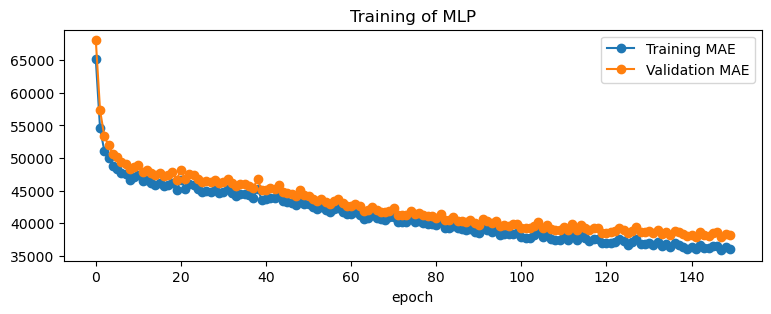

In [16]:
# plot training history
num_epochs = len(history_mlp['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(num_epochs), history_mlp['mae'], marker='o', label='Training MAE')
plt.plot(range(num_epochs), history_mlp['val_mae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of MLP')
plt.legend();

In [17]:
best_val_mae_log = float("inf")
best_state_log = None

loss_fn_mlp_log = nn.MSELoss()
optimizer_mlp_log = optim.Adam(model_mlp_log.parameters(), lr=0.001)
history_mlp_log = {"epoch": [], "mae": [], "val_mae": []}

for epoch in range(150):
    model_mlp_log.train()
    for xb, yb in train_loader_log:
        optimizer_mlp_log.zero_grad()
        yhat_train = model_mlp_log(xb)
        loss = loss_fn_mlp_log(yhat_train, yb)
        loss.backward()
        optimizer_mlp_log.step()

    model_mlp_log.eval()
    with torch.no_grad():
        train_pred_log = model_mlp_log(Xtrain_t).cpu().numpy().reshape(-1)
        val_pred_epoch_log = model_mlp_log(Xvalidate_t).cpu().numpy().reshape(-1)
    
    train_pred = np.expm1(np.clip(train_pred_log, -20, 20))
    val_pred_epoch = np.expm1(np.clip(val_pred_epoch_log, -20, 20))

    train_mae = mean_absolute_error(ytrain, train_pred)
    val_mae = mean_absolute_error(yvalidate, val_pred_epoch)

    history_mlp_log["epoch"].append(epoch)
    history_mlp_log["mae"].append(mean_absolute_error(ytrain, train_pred))
    history_mlp_log["val_mae"].append(mean_absolute_error(yvalidate, val_pred_epoch))

    if val_mae < best_val_mae_log:
        best_val_mae_log = val_mae
        best_state_log = {k: v.clone() for k, v in model_mlp_log.state_dict().items()}

model_mlp_log.load_state_dict(best_state_log)

val_pred_log = predict_model(model_mlp_log, Xvalidate_scaled)
val_pred_log_final = np.expm1(val_pred_log)
yvalidate_actual = yvalidate
mae_log = mean_absolute_error(yvalidate_actual, val_pred_log_final)
r2_log = r2_score(yvalidate_actual, val_pred_log_final)

print("validation MAE: ", mae_log)
print("validation R2: ", r2_log)

validation MAE:  35061.34130174347
validation R2:  0.7896936005189857


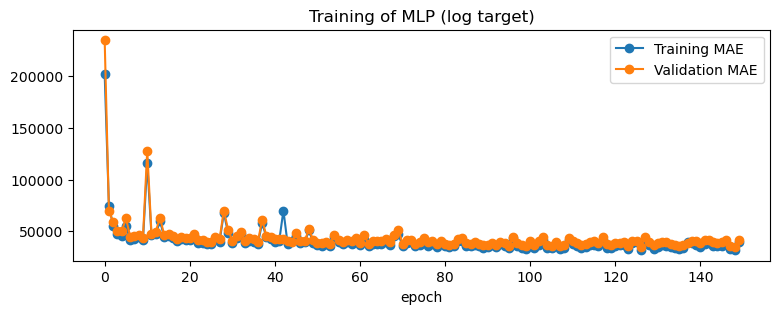

In [18]:
# plot training history
num_epochs = len(history_mlp_log['epoch'])
plt.figure(figsize=(9,3))
plt.plot(range(num_epochs), history_mlp_log['mae'], marker='o', label='Training MAE')
plt.plot(range(num_epochs), history_mlp_log['val_mae'], marker='o', label='Validation MAE')
plt.xlabel('epoch')
plt.title('Training of MLP (log target)')
plt.legend();

In [19]:
print(train_pred_log.min(), train_pred_log.max())

10.004861 13.75959


In [20]:
best_epoch = np.argmin(history_mlp_log["val_mae"])
print("Best epoch:", best_epoch)
print("Best val MAE:", history_mlp_log["val_mae"][best_epoch])

Best epoch: 148
Best val MAE: 35061.34130174347


In [23]:
mean_price_val = np.mean(yvalidate)
percent_error_val = mae_log / mean_price_val
print("val Percent Error:", percent_error_val)

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(yvalidate, val_pred_log_final)
print("MAPE:", mape)

val Percent Error: 0.16937609670328635
MAPE: 0.18460478789874574


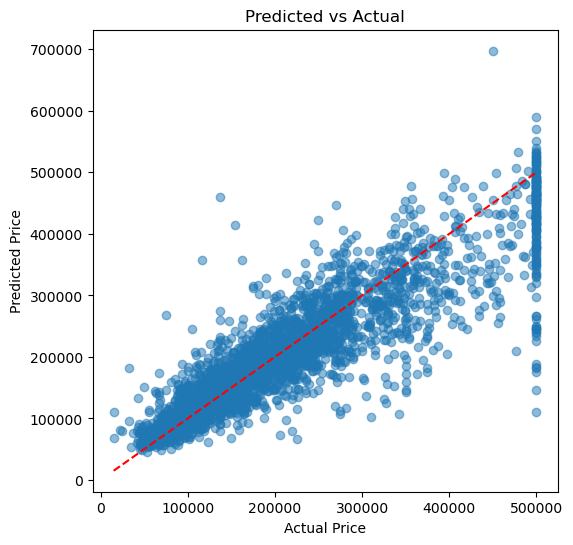

In [26]:
# plot actual vs predicted price for validation set
plt.figure(figsize=(6,6))
plt.scatter(yvalidate, val_pred_log_final, alpha=0.5)

# perfect prediction line
plt.plot([yvalidate.min(), yvalidate.max()],
         [yvalidate.min(), yvalidate.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()

In [ ]:
test_pred_log = predict_model(model_mlp_log, Xtest_scaled)
test_pred = np.expm1(test_pred_log)
mae_test = mean_absolute_error(ytest, test_pred)
r2_test = r2_score(ytest, test_pred)
print("Test MAE: ", mae_test)
print("Test R2: ", r2_test)

mean_price_test = np.mean(ytest)
percent_error_test = mae_test / mean_price_test
print("test Percent Error:", percent_error_test)

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(ytest, test_pred)
print("MAPE:", mape)

In [ ]:
# plot actual vs predicted price for test set
plt.figure(figsize=(6,6))
plt.scatter(ytest, test_pred, alpha=0.5)

# perfect prediction line
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()